# Checking images and summarizing floe statistics
* Enforce global minimum size of 64 pixels (8 by 8)
* Get minimum, maximum, mean, and count and add to table

In [ ]:
import pandas as pd
import numpy as np
import skimage as sk
import os
import ultraplot as uplt

In [8]:
dataloc = "../data/validation_dataset/binary_floes_init/"
min_area = 64
files = os.listdir(dataloc)
files.sort()
files = [f for f in files if 'DS_' not in f]

In [4]:
binary_images = {}
for f in files:
    case, region, date, satellite, imtype = f.split('-')
    case_name = case + '_' + satellite
    binary_images[case_name] = sk.io.imread(dataloc + f)

In [5]:
floe_stats = {}
for case_name in binary_images:
    if np.any(binary_images[case_name][:,:,0] > 0):
        labeled = sk.measure.label(binary_images[case_name][:, :, 0])
        df = pd.DataFrame(sk.measure.regionprops_table(labeled, properties=["label", "area"]))
        floe_stats[case_name] = [df.area.min(), df.area.mean(), df.area.max(), len(df)]
        
floe_stats = pd.DataFrame(floe_stats).T
floe_stats.columns = ["minimum", "mean", "maximum", "count"]

In [9]:
case_name = '006_terra'
labeled = sk.measure.label(binary_images[case_name][:, :, 0])
df = pd.DataFrame(sk.measure.regionprops_table(labeled, properties=["label", "area"]))
[df.area.min(), df.area.mean(), df.area.max(), len(df)]

[np.float64(17.0), np.float64(282.26881720430106), np.float64(3436.0), 186]

In [10]:
floe_stats.loc[floe_stats.minimum < min_area]

,minimum,mean,maximum,count
001_aqua,47.0,610.181818,4127.0,11.0
001_terra,50.0,629.636364,4296.0,11.0
002_aqua,46.0,278.500000,741.0,4.0
005_aqua,35.0,153.823529,951.0,17.0
005_terra,27.0,159.666667,924.0,24.0
...,...,...,...,...
171_terra,15.0,36.750000,73.0,4.0
175_aqua,43.0,52.000000,61.0,2.0
188_terra,49.0,77.250000,133.0,4.0
189_aqua,27.0,81.142857,137.0,7.0


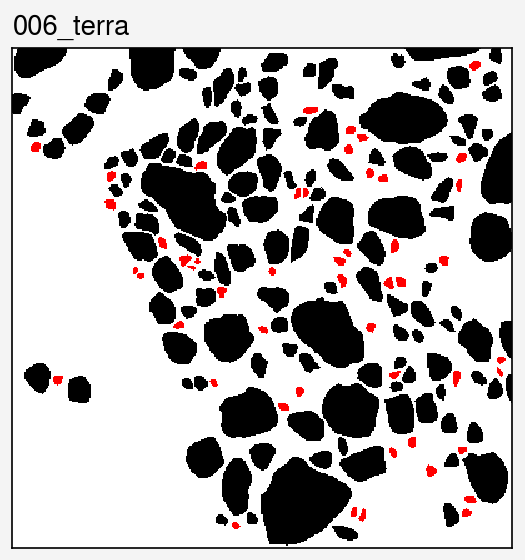

In [11]:
# Highlight floe which is too small
fig, ax = uplt.subplots()
labeled = sk.measure.label(binary_images[case_name][:,:,0])
updated = labeled.copy()

df = pd.DataFrame(sk.measure.regionprops_table(labeled, properties=["label", "area"]))

ax.imshow(np.ma.masked_array(labeled, mask=labeled == 0), color='k')
for label in df.loc[df.area < min_area, 'label']:
    updated[updated == label] = 0
    ax.imshow(np.ma.masked_array(labeled, mask=labeled != label), color='r')
    ax.format(ltitle=case_name, xticks='none', yticks='none')

In [ ]:
saveloc = '../data/validation_dataset/binary_floes'
for f in files:
    case, region, date, satellite, imtype = f.split('-')
    case_name = case + '_' + satellite

    labeled = sk.measure.label(binary_images[case_name][:,:,0])
    updated = labeled.copy()
    df = pd.DataFrame(sk.measure.regionprops_table(labeled, properties=["label", "area"]))
    if np.any(df.area.min() < min_area):
        for label in df.loc[df.area < min_area, 'label']:
            updated[updated == label] = 0
        
    sk.io.imsave(saveloc + '/' + f, (updated > 0).astype(np.uint8)*255)

# Update and extend the metadata table
- rename dataset file as "init" to not lose changes
- extract the "notes" column and place into a separate file

In [15]:
df = pd.read_csv('../data/validation_dataset/validation_dataset_init.csv')

In [ ]:
# Generate notes file
notes = df.notes.fillna("")
case_number = [str(x).zfill(3) for x in df.case_number]
satellite =  df.satellite

text = ""
for n, c, s in zip(notes, case_number, satellite):
    text += c + ', ' + s + ': ' + n + '\n'

with open('../data/metadata/case_notes.txt', 'w') as f:
    f.write(text)

In [30]:
columns = 'case_number', 'region', 'satellite', 'start_date', 'pass_time', 'center_lon',
       'center_lat', 'center_x', 'center_y', 'sea_ice_fraction', 'mean_sea_ice_concentration',
       'visible_sea_ice', 'visible_landfast_ice', 'visible_floes', 'visible_water',
        
        # tbd: cloud fraction modis
       'cloud_fraction_manual', 'cloud_category_manual', 'artifacts',
       'floe_obscuration', 'landfast_obscuration'

# update visible floes if none remain after small floe removal
df.columns

Index(['Unnamed: 0', 'case_number', 'region', 'start_date', 'center_lon',
       'center_lat', 'center_x', 'center_y', 'month', 'sea_ice_fraction',
       'mean_sea_ice_concentration', 'init_case_number', 'satellite',
       'visible_sea_ice', 'visible_landfast_ice', 'visible_floes',
       'visible_water', 'cloud_fraction_manual', 'cloud_category_manual',
       'artifacts', 'qa_analyst', 'qa_reviewer', 'fl_analyst', 'fl_reviewer',
       'psd_file', 'floe_obscuration', 'landfast_obscuration',
       'modis_cloud_error', 'notes', 'pass_time'],
      dtype='object')

In [46]:
new_cols = ['number_floes', 'mean_floe_size', 'total_floe_area', 'minimum_floe_size', 'maximum_floe_size']
df.loc[:, new_cols] = np.nan

for row, data in df.iterrows():
    case_name = str(data.case_number).zfill(3) + '_' + data.satellite
    if case_name in binary_images:
        if np.any(binary_images[case_name][:,:,0] > 0):
            labeled = sk.measure.label(binary_images[case_name][:, :, 0])
            df_regionprops = pd.DataFrame(sk.measure.regionprops_table(labeled, properties=["label", "area"]))
            df.loc[row, 'number_floes'] = len(df_regionprops)
            df.loc[row, 'minimum_floe_size'] = np.round(df_regionprops.area.min(), 0)
            df.loc[row, 'maximum_floe_size'] = np.round(df_regionprops.area.max(), 0)
            df.loc[row, 'mean_floe_size'] = np.round(df_regionprops.area.mean(), 1)
            df.loc[row, 'total_floe_area'] = np.sum(binary_images[case_name][:,:,0] > 0)
            
        else:
            df.loc[row, 'number_floes'] = 0
    else:
        df.loc[row, 'number_floes'] = 0
    

In [53]:
columns = ['case_number', 'region', 'satellite', 'start_date', 'pass_time', 'center_lon',
       'center_lat', 'center_x', 'center_y', 'sea_ice_fraction', 'mean_sea_ice_concentration',
       'visible_sea_ice', 'visible_landfast_ice', 'visible_floes', 'visible_water',
       'number_floes', 'mean_floe_size', 'total_floe_area', 'minimum_floe_size', 'maximum_floe_size',
        # tbd: cloud fraction modis
       'cloud_fraction_manual', 'cloud_category_manual', 'artifacts',
       'floe_obscuration', 'landfast_obscuration']

In [57]:
df.loc[:, columns].to_csv('../data/validation_dataset/validation_dataset.csv')

In [58]:
binary_images['001_aqua'].shape

(400, 400, 3)